In [2]:
# Kurdistan Business Registry analysing

import os
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# data loading
data_path = r"C:\Users\lanaa\Downloads\kurdistan_companies_combined.csv"
output_dir = "charts"    #where to save the charts
os.makedirs(output_dir, exist_ok=True)

In [4]:
# choosing a color pallete to make it look better adn colorfull so easy to understand
BRASS = "#bd8f45" # main bars
STAMP = "#a63a2c" # highlight / top item
TEAL = "#356e57" # secondary series
GREY = "#9c9c9c" # comparison / muted bars

plt.rcParams.update({
    "font.size": 10,
    "axes.edgecolor" : "#444444",
    "axes.grid" : True,
    "grid.color" : "#dddddd",
    "grid.linewidth" : 0.6,
    "axes.axisbelow" : True,
})

In [5]:
df = pd.read_csv(data_path)
df.head()

,companyId,uniqueEntityNumber,companyName,ceoName,ceoGender,establishedDate,companyType,companyOrigin,province,district,street,neighborhood,activityTypes,capital,shareholderNames,shareholderGender,shareholderNationality,shareholderNumberOfShares,shareholderPercentage,shareholderIdType
0,ZI19262791,20260104632986,مدار الامان,سيف محمود عنزي,male,2026-08-06,Private Limited,Local Company,Erbil,Erbil District,100m شەقامی پێشەوا قازی,كورانی عنگاوە,Car Rental; Logistics Consultancy; Transport C...,1000000.0,سيف محمود عنزي,male,iraqi,1000000,100,national_id
1,PW80781149,20260101727194,محمد هەڤال محمد صالح,محمد هەڤال محمد صالح,male,2026-08-06,Individual Project,Local Company,Sulaymaniyah,Sulaymaniyah District,کەریمی ئەلەکە,سابونکەران/204,Beauty & Personal Care Requisites Trading,1000000.0,محمد هەڤال محمد صالح,male,iraqi,1000000,100,national_id
2,NR99905986,20260104781840,.keep resource,ديدار رضا امين البرزنجي,male,2026-08-06,Private Limited,Local Company,Sulaymaniyah,Sulaymaniyah District,خاک,شۆڕش 109,Data Classification & Analysis Services,1000000.0,دیدار رضا امین,male,iraqi,1000000,100,national_id
3,II08743182,20260104222219,سیپانۆر,سروان ایوب حسین,male,2026-08-06,Private Limited,Local Company,Erbil,Erbil District,شەقامی 40 مەتری,بەرامبەر دەزگای ئاراس,Coffee Trading; General Trading,1000000.0,هشام ابوزید جلال,male,iraqi; iraqi,500000; 500000,50; 50,national_id; national_id
4,TY62688308,20260104836579,china mart,Zhengbo Zhang,male,2026-08-06,Private Limited,Local Company,Erbil,Erbil District,گوڵان,گوندی ئینگلیزی,Shopping Center (Mall),1000000.0,Luo Jiajia,female,foreigner; foreigner,900000; 100000,90; 10,passport; passport


In [6]:
df['year'] = df["establishedDate"].str.split("-").str[0]
df['year']

0        2026
1        2026
2        2026
3        2026
4        2026
         ... 
15536    1998
15537    1998
15538    1998
15539    1998
15540    1998
Name: year, Length: 15541, dtype: object

In [9]:
# in case we had more than one activity type we can make them listed rather than just splited with ";"
activities = (
    df['activityTypes']
    .dropna()
    .str.split(";")
    .explode()
    .str.strip()
)

In [11]:
# for saving out figures the way we want we can use this method or directly save it through plt.savefig()
def savefig(fig, name):
    path = os.path.join(output_dir, name)
    fig.tight_layout()
    fig.savefig(path, dpi=150)
    plt.close(fig)
    print(f"saved {path}")

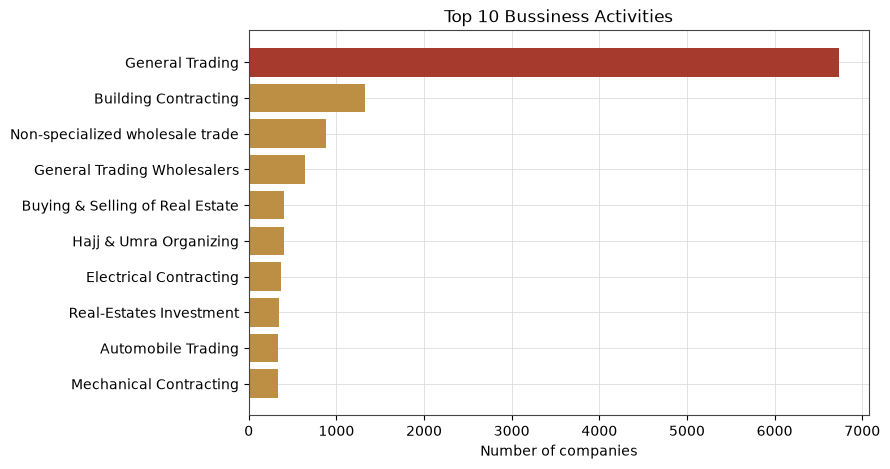

saved charts\top10_activities.png


In [145]:
### extracting and representing the most common activities
top_activities = activities.value_counts().head(10).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
colors = [STAMP if i == top_activities.max() else BRASS for i in top_activities.values]
ax.barh(top_activities.index, top_activities.values, color=colors)
ax.set_title("Top 10 Bussiness Activities")
ax.set_xlabel("Number of companies")
plt.show()
savefig(fig, "top10_activities.png")

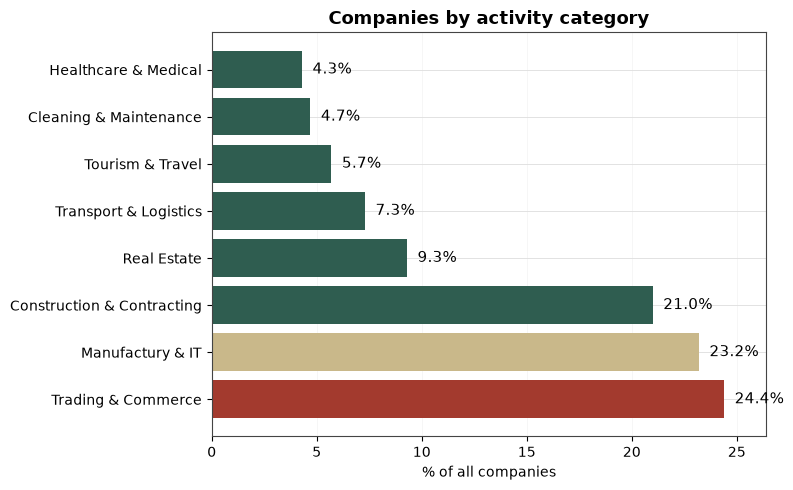

saved charts\categories.png


In [55]:
# sorting these activities into different sectors
category_keywords = {
    "Trading & Commerce" : ["tred", "wholesale", "retail", "selling"],
    "Construction & Contracting" : ["contract", "construction"],
    "Real Estate" : ["real estate", "real-estate"],
    "Tourism & Travel" : ["tourism", "travel" , "hajj", "umra"],
    "Transport & Logistics" : ["transport", "logistic"],
    "Manufactury & IT" : ["it", "software", "technology", "information technology"],
    "Cleaning & Maintenance" : ["cleaning", "maintenance"],
    "Healthcare & Medical" : ["health", "medical", "pharma"],
}

n_companies = len(df)

# match at company level directory on the raw activity Type, and calculate percentage
total = cat_series.sum() 
cat_pct = (cat_series / total * 100).round(1) 
#sort descending 
cat_pct = cat_pct.sort_values(ascending=False) 
#colors (first bar cherry red, second beige others dark green)
colors = ['#A33A2E' if i == 0 else '#C9B88A' if i == 1 else '#2F5D50' for i in range(len(cat_pct))]  
#plot 
fig, ax = plt.subplots(figsize=(8,5))
bars = ax.barh(cat_pct.index, cat_pct.values, color=colors) 
# add percentage labels at the end of each bar 
for bar,pct in zip(bars, cat_pct.values):
    width = bar.get_width() 
    ax.text(width +0.5, bar.get_y() + bar.get_height()/2, f'{pct}%', va='center', ha='left', fontsize=11, color='black') 
# formatting 
ax.set_xlabel('% of all companies')
ax.set_title('Companies by activity category',fontsize=13, weight='semibold')
ax.set_xlim(0, max(cat_pct.values) + 2) 
ax.xaxis.grid(True, alpha=0.3) 
ax.set_axisbelow(True) 
plt.tight_layout() 
plt.show() 
savefig(fig, 'categories.png') 



In [61]:
### Yearly filling
yearly = df['year'].value_counts().sort_index()
cumulative = yearly.cumsum()

In [63]:
cumulative

year
1998       38
1999       82
2000      142
2001      181
2002      220
2003      241
2004      405
2005      650
2006      961
2007     1245
2008     1613
2009     1979
2010     2335
2011     2687
2012     3168
2013     3725
2014     4110
2015     4496
2016     4793
2017     5168
2018     5492
2019     6128
2020     6595
2021     7280
2022     7877
2023     9844
2024    12088
2025    14325
2026    15541
Name: count, dtype: int64

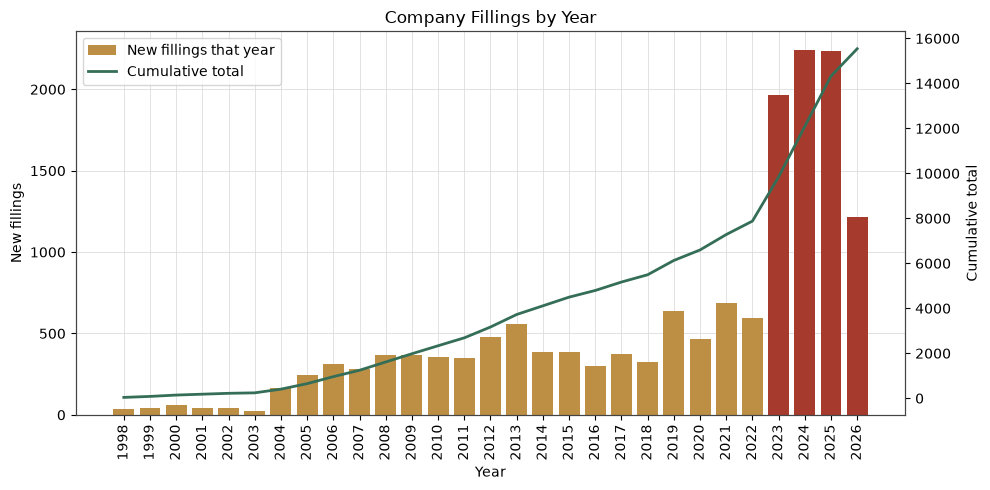

saved charts\yearly_filling.png


In [143]:
fig, ax1 = plt.subplots(figsize=(10, 5))
colors = [STAMP if y >= '2023' else BRASS for y in yearly.index]
ax1.bar(yearly.index.astype(str), yearly.values, color=colors, label="New fillings that year")
ax1.set_ylabel("New fillings")
ax1.set_xlabel("Year")
ax1.tick_params(axis="x", rotation=90)

ax2 = ax1.twinx()
ax2.plot(yearly.index.astype(str), cumulative.values, color="#356e57", linewidth=2, label='Cumulative total')
ax2.set_ylabel("Cumulative total")
ax2.grid(False)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

ax1.set_title("Company Fillings by Year")
plt.tight_layout()
plt.show()
savefig(fig, "yearly_filling.png")

In [71]:
savefig(fig, "yearly_fillings.png")

saved charts\yearly_fillings.png


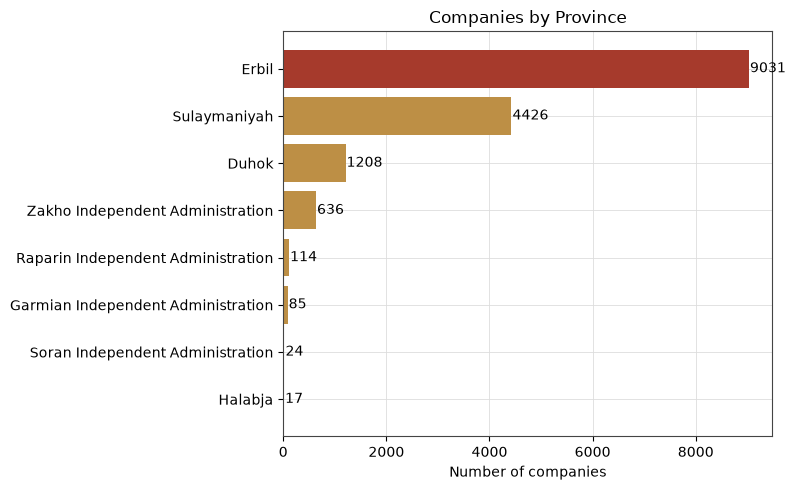

saved charts\province_counts.png


In [142]:
### Companies per province
province_counts = df['province'].value_counts().sort_values()

fig, ax = plt.subplots(figsize=(8,5))
colors = [STAMP if i == len(province_counts) - 1 else BRASS for i in range(len(province_counts))]

bars = ax.barh(province_counts.index, province_counts.values)

for bar in bars:
    ax.text(
        bar.get_width() + 20,
        bar.get_y() + bar.get_height() / 2, 
        f'{int(bar.get_width())}',
    va='center'
    )
ax.barh(province_counts.index, province_counts.values, color=colors)
ax.set_title("Companies by Province")
ax.set_xlabel("Number of companies")
plt.tight_layout()
plt.show()
savefig(fig, "province_counts.png")

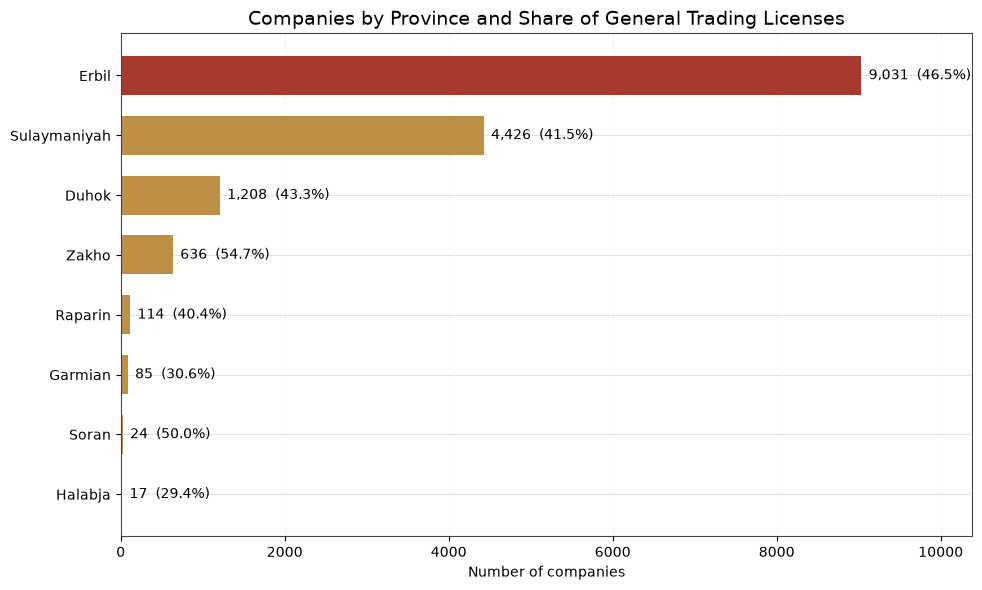

saved charts\companies_by_province.png


In [146]:
# Number of companies in each province
province_counts = df['province'].value_counts()

# Rename provinces for the chart
province_counts = province_counts.rename(index={
    'Soran Independent Administration': 'Soran',
    'Zakho Independent Administration': 'Zakho',
    'Garmian Independent Administration': 'Garmian',
    'Raparin Independent Administration': 'Raparin'
})

# Identify General Trading companies
general_trading = df['activityTypes'].str.contains(
    'General Trading',
    case=False,
    na=False
)

# Percentage of General Trading companies within each province
general_trading_pct = (
    general_trading.groupby(df['province']).mean() * 100
)

# Rename percentage index the same way
general_trading_pct = general_trading_pct.rename(index={
    'Soran Independent Administration': 'Soran',
    'Zakho Independent Administration': 'Zakho',
    'Garmian Independent Administration': 'Garmian',
    'Raparin Independent Administration': 'Raparin'
})

province_counts = province_counts.sort_values()

# Create figure 
fig, ax = plt.subplots(figsize=(10, 6))

colors = [STAMP if value == province_counts.max() else BRASS for value in province_counts.values]

bars = ax.barh(province_counts.index,province_counts.values,color=colors,height=0.65)

# adding the number and percentage of each province that have general trade activities
for bar, province in zip(bars, province_counts.index):

    number = int(bar.get_width())
    percentage = general_trading_pct.get(province, 0)

    ax.text(bar.get_width() + province_counts.max() * 0.01,bar.get_y() + bar.get_height() / 2,f'{number:,}  ({percentage:.1f}%)',va='center',fontsize=10)

ax.set_title('Companies by Province and Share of General Trading Licenses',fontsize=14)
ax.set_xlabel('Number of companies')
ax.set_axisbelow(True)
ax.grid(axis='x',linestyle='-',alpha=0.3)
ax.set_xlim(0,province_counts.max() * 1.15)
plt.tight_layout()
plt.show()

savefig(fig, "companies_by_province.png")

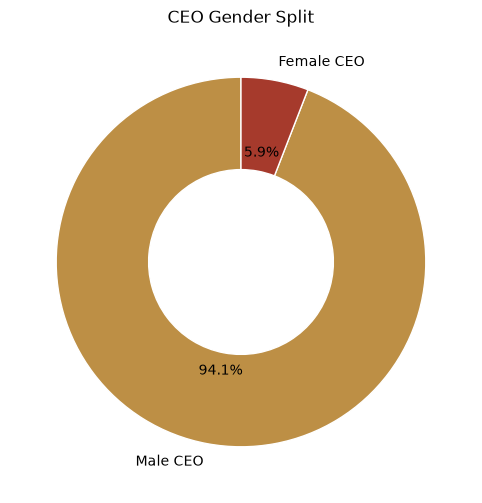

saved charts\ceo_gender_split


In [133]:
### CEO gender split
single_ceo = df[df['ceoGender'].isin(['male', 'female'])]
gender_counts = single_ceo['ceoGender'].value_counts()
all_male_pct = 100 * gender_counts.get('male', 0) / gender_counts.sum()
has_female_pct = 100 * gender_counts.get('female', 0) / gender_counts.sum()

fig, ax = plt.subplots(figsize=(6,6))
ax.pie([all_male_pct, has_female_pct], labels=['Male CEO', 'Female CEO'],
       colors = [BRASS, STAMP],
       autopct='%.1f%%',
       startangle=90,
       wedgeprops={"width":0.5, "edgecolor":"white"},
      )
ax.set_title("CEO Gender Split")

savefig(fig, "ceo_gender_split")

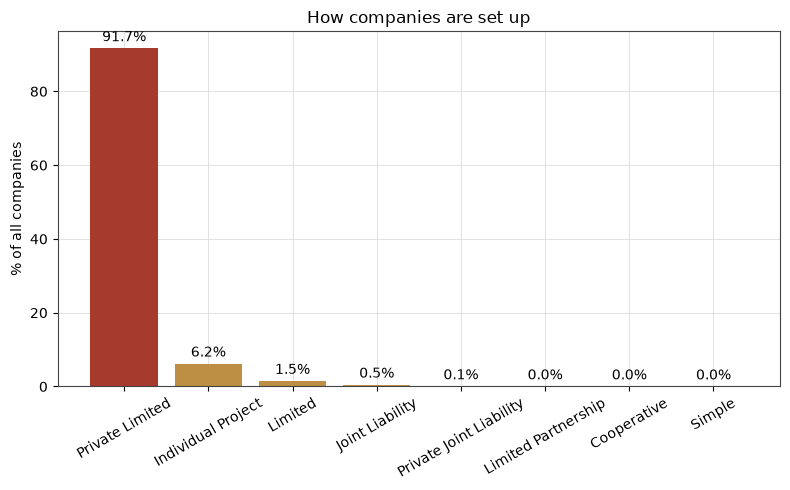

saved charts\company_type_breakdown.png


In [134]:
# Company type breakdown

type_pct = 100 * df["companyType"].value_counts(normalize=True)

fig, ax = plt.subplots(figsize=(8, 5))
colors = [STAMP if i == 0 else BRASS for i in range(len(type_pct))]
bars = ax.bar(type_pct.index,type_pct.values,color=colors)

# Adding percentage above each bar
for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f'{bar.get_height():.1f}%',
        ha='center',
        va='bottom'
    )
    
ax.set_title("How companies are set up")
ax.set_ylabel("% of all companies")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()
savefig(fig, "company_type_breakdown.png")

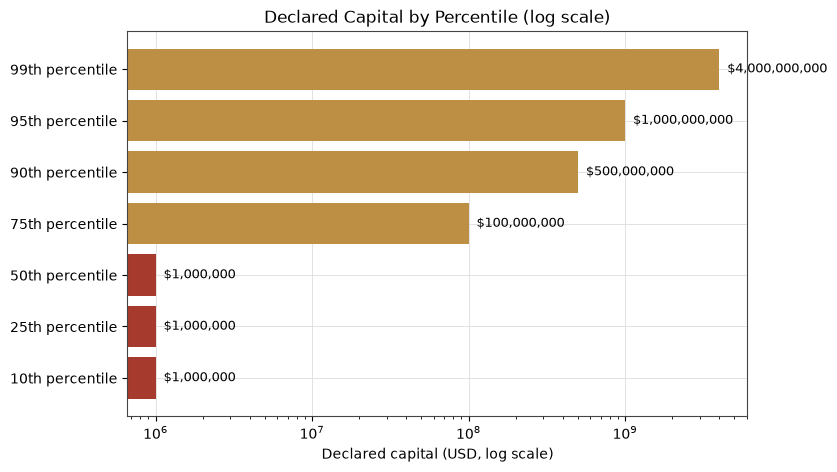

saved charts\capital_percentage.png


In [135]:
percentiles = [10, 25, 50, 75, 90, 95, 99]
capital_values = df["capital"].dropna()
capital_at_pct = {p: capital_values.quantile(p / 100) for p in percentiles}
 
labels = [f"{p}th percentile" for p in percentiles]
values = list(capital_at_pct.values())
 
fig, ax = plt.subplots(figsize=(8, 5))
colors = [STAMP if p <= 50 else BRASS for p in percentiles]
ax.barh(labels, values, color=colors)
ax.set_xscale("log")
ax.set_title("Declared Capital by Percentile (log scale)")
ax.set_xlabel("Declared capital (USD, log scale)")

# print the real dollar value at the end of each bar
for i, v in enumerate(values):
    ax.text(v, i, f"  ${v:,.0f}", va="center", fontsize=9)
plt.show()
savefig(fig, "capital_percentage.png")